# 02 - EDA 
**Objetivo:** usar gráficos para descubrir qué características distinguen a un fumador de un no fumador.



In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargo los datos etiquetados
train = pd.read_excel("../data/raw/smoking_train_labeled.xlsx")

print("Datos cargados:", train.shape)


Datos cargados: (50000, 27)


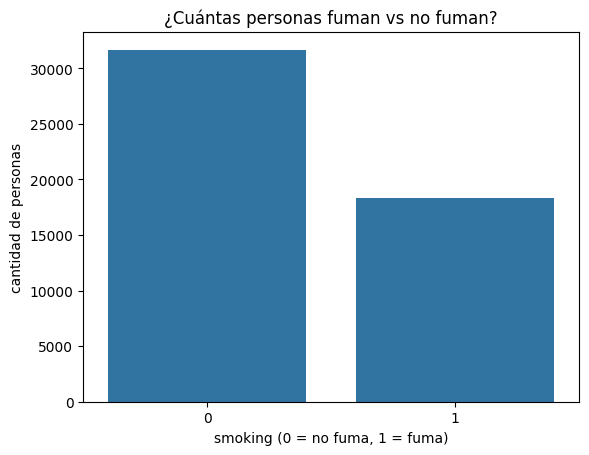

In [2]:
#ver en graficos cuantos fuman y cuantos no,
sns.countplot(data=train, x="smoking")
plt.title("¿Cuántas personas fuman vs no fuman?")
plt.xlabel("smoking (0 = no fuma, 1 = fuma)")
plt.ylabel("cantidad de personas")
plt.show()

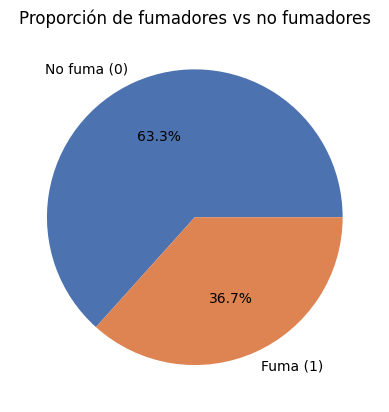

In [3]:
# Gráfico de torta: proporción de fumadores vs no fumadores
train["smoking"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",                      # muestra el % en cada porción
    labels=["No fuma (0)", "Fuma (1)"],
    colors=["#4C72B0", "#DD8452"]
)
plt.title("Proporción de fumadores vs no fumadores")
plt.ylabel("")   # saca un texto feo que pandas pone por defecto
plt.show()


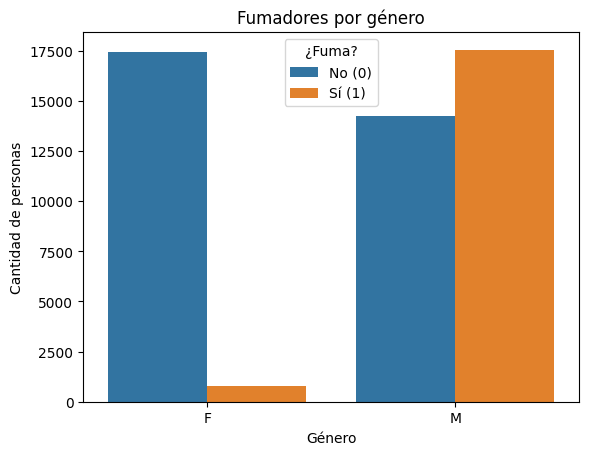

In [4]:
# Fumadores y no fumadores, separados por hombre y mujer
sns.countplot(data=train, x="gender", hue="smoking")
plt.title("Fumadores por género")
plt.xlabel("Género")
plt.ylabel("Cantidad de personas")
plt.legend(title="¿Fuma?", labels=["No (0)", "Sí (1)"])
plt.show()


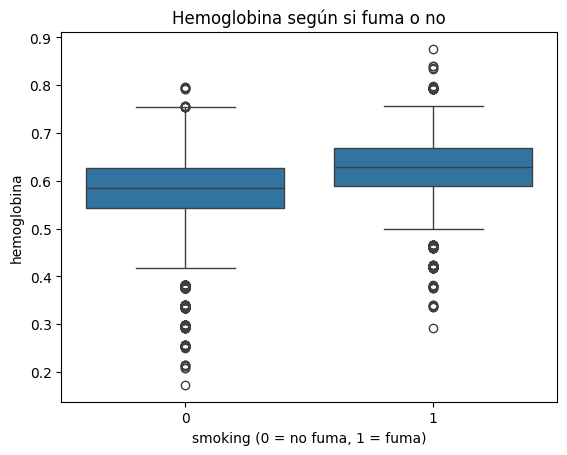

In [5]:
# Boxplot: comparo la hemoglobina entre no fumadores (0) y fumadores (1)
sns.boxplot(data=train, x="smoking", y="hemoglobin")
plt.title("Hemoglobina según si fuma o no")
plt.xlabel("smoking (0 = no fuma, 1 = fuma)")
plt.ylabel("hemoglobina")
plt.show()


## Conclusiones del EDA

- El target está **desbalanceado** (~63% no fuma, ~37% fuma) → por eso evaluaremos con **F1-Score** de la clase 1, no con accuracy.
- **`gender` es el predictor más fuerte**: ~52% de los hombres fuma, contra solo ~6% de las mujeres.
- Variables numéricas que más se relacionan con **fumar** (positivo): `height`, `hemoglobin`, `weight`, `triglyceride`, `Gtp`, `waist`. Valores altos → más probable que fume.
- Variables que se relacionan con **NO fumar** (negativo): `HDL` (colesterol bueno) y `age`.
- **Ninguna variable sola es decisiva** (correlaciones moderadas, máx ~0,40) → el modelo tendrá que **combinar muchas pistas**.
- `height` funciona en parte como "espejo" del género (los hombres son más altos y fuman más).
- Confirmamos dos cosas para el preprocesamiento: hay que **convertir las columnas de texto a número** y **escalar** (las variables están en escalas muy distintas).
